1、导入依赖库

In [30]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams

rcParams['font.sans-serif'] = ['SimHei'] # 设置字体
plt.rcParams['axes.unicode_minus'] = False

2、导入数据

In [31]:
prop_mkt_df = pd.read_csv("house_sales.csv")

3、数据概览

In [32]:
print("总记录数量：", len(prop_mkt_df))
print("字段数量：", len(prop_mkt_df.columns))
print("数据信息:")
display(prop_mkt_df.head(10))

总记录数量： 106118
字段数量： 12
数据信息:


,city,address,area,floor,name,price,province,rooms,toward,unit,year,origin_url
0,合肥,龙岗-临泉东路和王岗大道交叉口东南角,90㎡,中层（共18层）,圣地亚哥,128万,安徽,3室2厅,南北向,14222元/㎡,2013年建,https://hf.esf.fang.com/chushou/3_404230646.htm
1,合肥,龙岗-临泉东路和王岗大道交叉口东南角,90㎡,中层（共18层）,圣地亚哥,128万,安徽,3室2厅,南北向,14222元/㎡,2013年建,https://hf.esf.fang.com/chushou/3_404230646.htm
2,合肥,生态公园-淮海大道与大众路交口,95㎡,中层（共18层）,正荣·悦都荟,132万,安徽,3室2厅,南向,13895元/㎡,2019年建,https://hf.esf.fang.com/chushou/3_404304901.htm
3,合肥,生态公园-淮海大道与大众路交口,95㎡,中层（共18层）,正荣·悦都荟,132万,安徽,3室2厅,南向,13895元/㎡,2019年建,https://hf.esf.fang.com/chushou/3_404304901.htm
4,合肥,撮镇-文一名门金隅裕溪路与东风大道交口,37㎡,中层（共22层）,文一名门金隅,32万,安徽,2室1厅,南北向,8649元/㎡,2017年建,https://hf.esf.fang.com/chushou/3_404372096.htm
5,合肥,撮镇-文一名门金隅裕溪路与东风大道交口,37㎡,中层（共22层）,文一名门金隅,32万,安徽,2室1厅,南北向,8649元/㎡,2017年建,https://hf.esf.fang.com/chushou/3_404372096.htm
6,合肥,龙岗-长江东路与和县里交口,50㎡,高层（共30层）,柏庄金座,46万,安徽,2室1厅,南向,9200元/㎡,2019年建,https://hf.esf.fang.com/chushou/3_398859799.htm
7,合肥,龙岗-长江东路与和县里交口,50㎡,高层（共30层）,柏庄金座,46万,安徽,2室1厅,南向,9200元/㎡,2019年建,https://hf.esf.fang.com/chushou/3_398859799.htm
8,合肥,新亚汽车站-张洼路与临泉路交汇处向北100米(原红星机械,120㎡,中层（共27层）,天目未来,158万,安徽,4室2厅,南向,13167元/㎡,2012年建,https://hf.esf.fang.com/chushou/3_381138154.htm
9,合肥,新亚汽车站-张洼路与临泉路交汇处向北100米(原红星机械,120㎡,中层（共27层）,天目未来,158万,安徽,4室2厅,南向,13167元/㎡,2012年建,https://hf.esf.fang.com/chushou/3_381138154.htm


In [33]:
print(prop_mkt_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106118 entries, 0 to 106117
Data columns (total 12 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   city        106118 non-null  object
 1   address     104452 non-null  object
 2   area        105324 non-null  object
 3   floor       104024 non-null  object
 4   name        105564 non-null  object
 5   price       105564 non-null  object
 6   province    106118 non-null  object
 7   rooms       104036 non-null  object
 8   toward      105240 non-null  object
 9   unit        105564 non-null  object
 10  year        57736 non-null   object
 11  origin_url  105564 non-null  object
dtypes: object(12)
memory usage: 9.7+ MB
None


4、数据清洗

In [34]:
prop_mkt_df.drop(columns="origin_url", inplace=True) # 删除数据来源链接
print("每一字段的缺失值的数量：")
print(pd.isna(prop_mkt_df).sum())

每一字段的缺失值的数量：
city            0
address      1666
area          794
floor        2094
name          554
price         554
province        0
rooms        2082
toward        878
unit          554
year        48382
dtype: int64


In [35]:
print("每一条数据(行)的缺失值数量：")
na_rows = prop_mkt_df.isna().sum(axis=1)
print(na_rows)

每一条数据(行)的缺失值数量：
0         0
1         0
2         0
3         0
4         0
         ..
106113    1
106114    1
106115    1
106116    1
106117    1
Length: 106118, dtype: int64


In [36]:
prop_mkt_df.head()

,city,address,area,floor,name,price,province,rooms,toward,unit,year
0,合肥,龙岗-临泉东路和王岗大道交叉口东南角,90㎡,中层（共18层）,圣地亚哥,128万,安徽,3室2厅,南北向,14222元/㎡,2013年建
1,合肥,龙岗-临泉东路和王岗大道交叉口东南角,90㎡,中层（共18层）,圣地亚哥,128万,安徽,3室2厅,南北向,14222元/㎡,2013年建
2,合肥,生态公园-淮海大道与大众路交口,95㎡,中层（共18层）,正荣·悦都荟,132万,安徽,3室2厅,南向,13895元/㎡,2019年建
3,合肥,生态公园-淮海大道与大众路交口,95㎡,中层（共18层）,正荣·悦都荟,132万,安徽,3室2厅,南向,13895元/㎡,2019年建
4,合肥,撮镇-文一名门金隅裕溪路与东风大道交口,37㎡,中层（共22层）,文一名门金隅,32万,安徽,2室1厅,南北向,8649元/㎡,2017年建


In [37]:
print("包含缺失值的行数：", len(na_rows[na_rows > 0]))
print("无缺失值的行数：", len(na_rows[na_rows == 0]))
df = prop_mkt_df.dropna().copy() # 丢弃包含缺失值的行

df["area"] = df["area"].str.replace("㎡", "").astype(float)
df["price"] = df["price"].str.replace("万", "").astype(float)
df["unit"] = df["unit"].str.replace("元/㎡", "").astype(float)
df["year"] = df["year"].str.replace("年建", "").astype(int)

print("重复数量：",df.duplicated().sum())
df = df.drop_duplicates() # 丢弃重复值
print("去重之后的数量：",len(df))
# 面积异常值处理
df = df[(df["area"] < 600) & (df["area"] > 20)]

# 计算IQR，丢弃异常值
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
df = df[(df["price"] > lower) & (df["price"] < upper)]

print("有效数量：", len(df))


包含缺失值的行数： 48598
无缺失值的行数： 57520
重复数量： 29416
去重之后的数量： 28104
有效数量： 26135


In [38]:
df.head(10)

,city,address,area,floor,name,price,province,rooms,toward,unit,year
0,合肥,龙岗-临泉东路和王岗大道交叉口东南角,90.0,中层（共18层）,圣地亚哥,128.0,安徽,3室2厅,南北向,14222.0,2013
2,合肥,生态公园-淮海大道与大众路交口,95.0,中层（共18层）,正荣·悦都荟,132.0,安徽,3室2厅,南向,13895.0,2019
4,合肥,撮镇-文一名门金隅裕溪路与东风大道交口,37.0,中层（共22层）,文一名门金隅,32.0,安徽,2室1厅,南北向,8649.0,2017
6,合肥,龙岗-长江东路与和县里交口,50.0,高层（共30层）,柏庄金座,46.0,安徽,2室1厅,南向,9200.0,2019
8,合肥,新亚汽车站-张洼路与临泉路交汇处向北100米(原红星机械,120.0,中层（共27层）,天目未来,158.0,安徽,4室2厅,南向,13167.0,2012
10,合肥,骆岗-东二环路与南淝河路交口东南,94.7,低层（共26层）,金隅大成郡,168.0,安徽,3室2厅,南向,17740.0,2019
12,重庆,礼嘉-光照路附近 (金通大道与金海大道交界处步行5,123.0,低层（共8层）,礼悦江山,176.5,直辖市,4室2厅,南向,14350.0,2019
16,合肥,撮镇-裕溪路与东风大道交口,32.0,中层（共28层）,文一名门金隅,25.0,安徽,2室1厅,南向,7812.0,2018
18,合肥,龙岗-临泉东路与通达路交口西北,83.0,低层（共6层）,静安新天地,99.0,安徽,2室2厅,南北向,11928.0,2012
20,合肥,合钢-上海路与滨河路交口,56.0,低层（共28层）,一尔悦城,52.0,安徽,3室2厅,南北向,9286.0,2019


5、新数据特征构造

In [39]:
def fun(str1):
    type_str = ["低", "中", "高"]
    for t in type_str:
        if t in str1:
            return t + "楼层"
    return "未知"

df["floor_type"] = df["floor"].apply(fun).astype('category')
df["nfloors"] = df["floor"].str.extract(r'(\d+)层').astype(int)
df["bedrooms"] = df["rooms"].str[0].astype(int)
df["living_rooms"] = df["rooms"].str.extract(r'(\d+)厅').astype(int)
df["age"] = pd.Timestamp.now().year - df["year"]
df["is_ZXS"] = df["city"].apply(lambda x: 1 if x in ["北京", "天津", "上海", "重庆"] else 0)
df["price_label"] = pd.cut(df["price"], bins=4, labels=["低价", "中价", "高价", "豪华"])
df["toward"] = df["toward"].astype('category')

In [40]:
df.head()

,city,address,area,floor,name,price,province,rooms,toward,unit,year,floor_type,nfloors,bedrooms,living_rooms,age,is_ZXS,price_label
0,合肥,龙岗-临泉东路和王岗大道交叉口东南角,90.0,中层（共18层）,圣地亚哥,128.0,安徽,3室2厅,南北向,14222.0,2013,中楼层,18,3,2,13,0,中价
2,合肥,生态公园-淮海大道与大众路交口,95.0,中层（共18层）,正荣·悦都荟,132.0,安徽,3室2厅,南向,13895.0,2019,中楼层,18,3,2,7,0,中价
4,合肥,撮镇-文一名门金隅裕溪路与东风大道交口,37.0,中层（共22层）,文一名门金隅,32.0,安徽,2室1厅,南北向,8649.0,2017,中楼层,22,2,1,9,0,低价
6,合肥,龙岗-长江东路与和县里交口,50.0,高层（共30层）,柏庄金座,46.0,安徽,2室1厅,南向,9200.0,2019,高楼层,30,2,1,7,0,低价
8,合肥,新亚汽车站-张洼路与临泉路交汇处向北100米(原红星机械,120.0,中层（共27层）,天目未来,158.0,安徽,4室2厅,南向,13167.0,2012,中楼层,27,4,2,14,0,高价


6、数据分析及其可视化

unit       0.742731
area       0.452523
age        0.091520
nfloors    0.052147
Name: price, dtype: float64

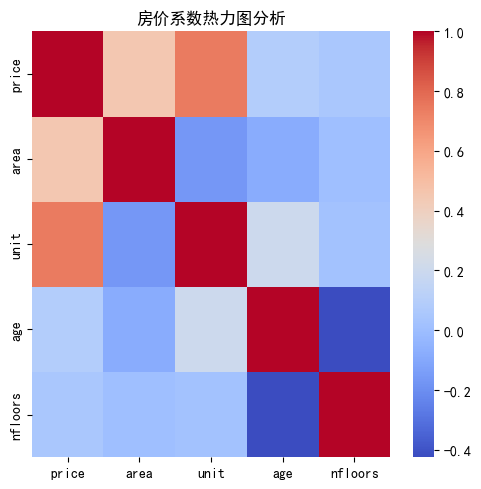

In [41]:
# 探究哪些变量对房价影响最大

# 求相关系数
relation = df[['price', 'area', 'unit', 'age', 'nfloors']].corr()
# 对价格的相关系数进行排序
display(relation["price"].sort_values(ascending=False)[1:])

# 绘制相关系数的热力图
plt.figure(figsize=(5,5))
sns.heatmap(relation, cmap="coolwarm")
plt.title("房价系数热力图分析")
plt.tight_layout()
plt.show()

,area,price,unit,year,nfloors,bedrooms,living_rooms,age,is_ZXS
count,26135.000000,26135.000000,26135.000000,26135.000000,26135.000000,26135.000000,26135.000000,26135.000000,26135.000000
mean,103.755810,117.208370,11610.131012,2013.072240,20.346776,2.714444,1.848556,12.927760,0.008800
std,33.995994,60.967675,5824.245273,6.019342,10.478639,0.800768,0.407353,6.019342,0.093399
min,21.000000,9.000000,1000.000000,1976.000000,1.000000,0.000000,0.000000,3.000000,0.000000
25%,85.005000,72.000000,7587.000000,2011.000000,11.000000,2.000000,2.000000,9.000000,0.000000
50%,100.000000,103.000000,10312.000000,2015.000000,20.000000,3.000000,2.000000,11.000000,0.000000
75%,123.000000,150.000000,14184.000000,2017.000000,30.000000,3.000000,2.000000,15.000000,0.000000
max,470.000000,306.000000,85288.000000,2023.000000,90.000000,9.000000,12.000000,50.000000,1.000000


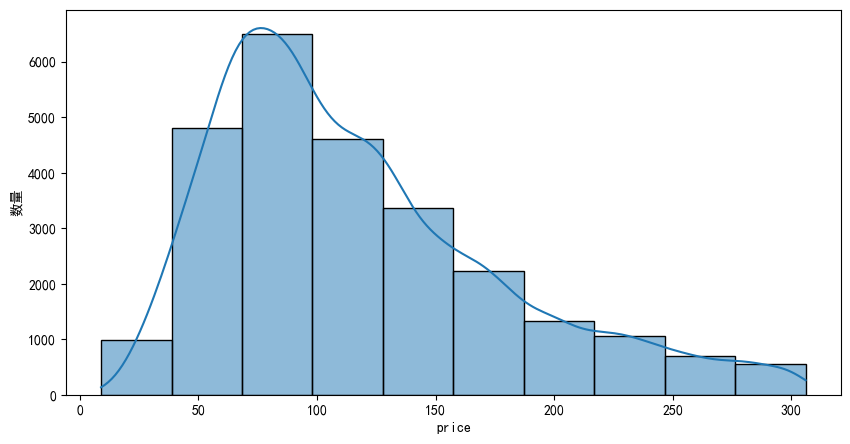

             price
price_label       
低价            9173
中价           11103
高价            4168
豪华            1691


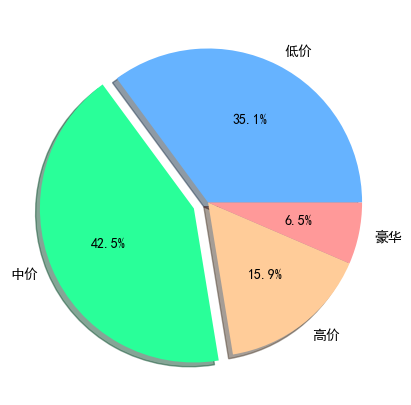

房价异常数量： 751
房价异常低数量： 0
房价异常高数量： 751


In [49]:
# 房价分布如何
display(df.describe())
plt.figure(figsize=(10,5))
sns.histplot(data=df, x='price', bins=10, kde=True)
plt.ylabel("数量")
plt.show()

price_groups = df.groupby('price_label', observed=True).agg({
    'price':'count',
})
print(price_groups)
max_id = price_groups['price'].tolist().index(max(price_groups['price']))

plt.figure(figsize=(10,5))
plt.pie(data=price_groups,
        x=price_groups['price'],
        labels=price_groups.index.tolist(),
        autopct='%.1f%%',
        shadow=True,
        colors=['#66b3ff','#29ff99','#ffcc99','#ff9999','#ff4499'],
        explode=[0.1 if i == max_id else 0 for i in range(len(price_groups))])
plt.show()
price_info = df.describe()['price']
Q1 = price_info.loc['25%']
Q3 =  price_info.loc['75%']
IQR = Q3 - Q1
lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR
print("房价异常数量：", len(df[(df["price"] < lower) | (df["price"] > upper)]))
print("房价异常低数量：", len(df[df["price"] < lower]))
print("房价异常高数量：", len(df[df["price"] > upper]))


城市房价统计：


price                        unit               
            mean  median count          mean   median count
city                                                       
深圳    250.769231  266.00    13  47923.307692  42190.0    13
安吉    228.325000  224.65     4  12733.000000  13135.5     4
苏州    210.793056  212.50    72  24088.111111  22797.5    72
温州    207.841667  219.40    48  21251.270833  22348.5    48
淳安    206.106667  208.00    45  27942.377778  29563.0    45
厦门    201.264706  209.00    17  25074.705882  26018.0    17
三亚    200.641026  198.00    39  23463.948718  22115.0    39
镇海    198.533824  220.00    68  22434.926471  24388.5    68
罗源    198.501064  205.00    47  22831.957447  21845.0    47
象山    197.247213  215.00    61  21748.147541  23030.0    61

房价前十： ['深圳', '安吉', '苏州', '温州', '淳安', '厦门', '三亚', '镇海', '罗源', '象山']


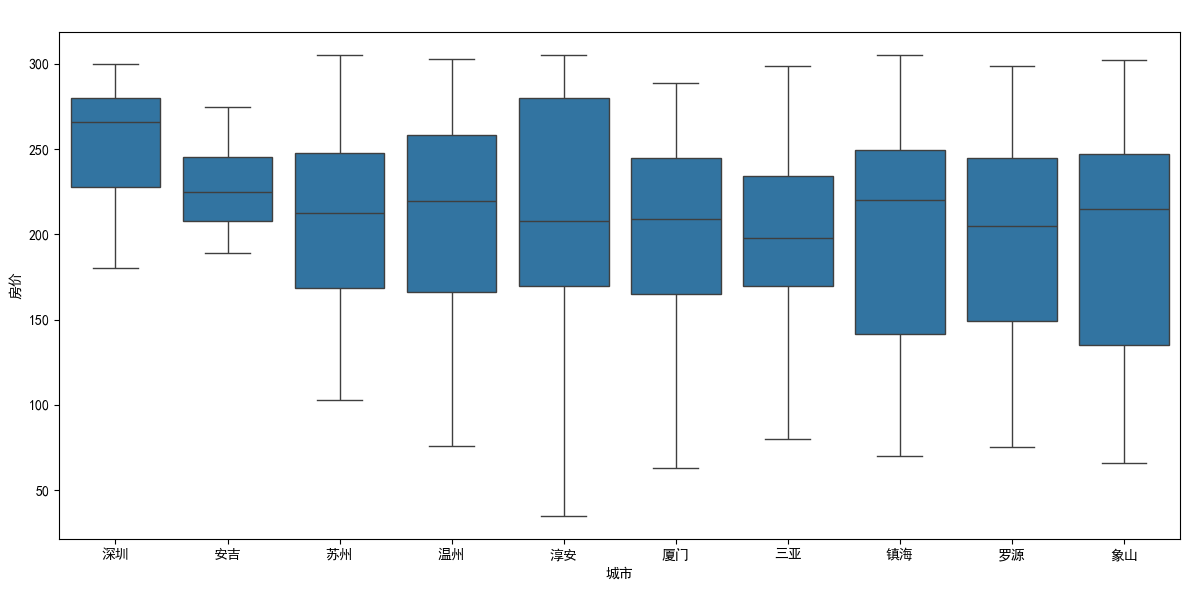

In [43]:
# 哪些城市房价最高

city_stats = df.groupby('city').agg({
    'price': ['mean', 'median', 'count'],
    'unit': ['mean', 'median', 'count'],
})
print("城市房价统计：")
display(city_stats.sort_values(('price', 'mean'), ascending=False).head(10))
top_cities = city_stats.sort_values(('price', 'mean'), ascending=False).head(10).index.tolist()
print("房价前十：",top_cities)
df_top = df[df['city'].isin(top_cities)]
plt.figure(figsize=(12,6))
sns.boxplot(data=df_top, x='city', y='price', order=top_cities)
plt.title("全国房价前十城市房价分布图", color='white')
plt.xlabel("城市")
plt.ylabel("房价")
plt.tight_layout()
plt.show()

             price       
              mean median
is_ZXS                   
非直辖市    116.927275  103.0
直辖市     148.868174  130.0


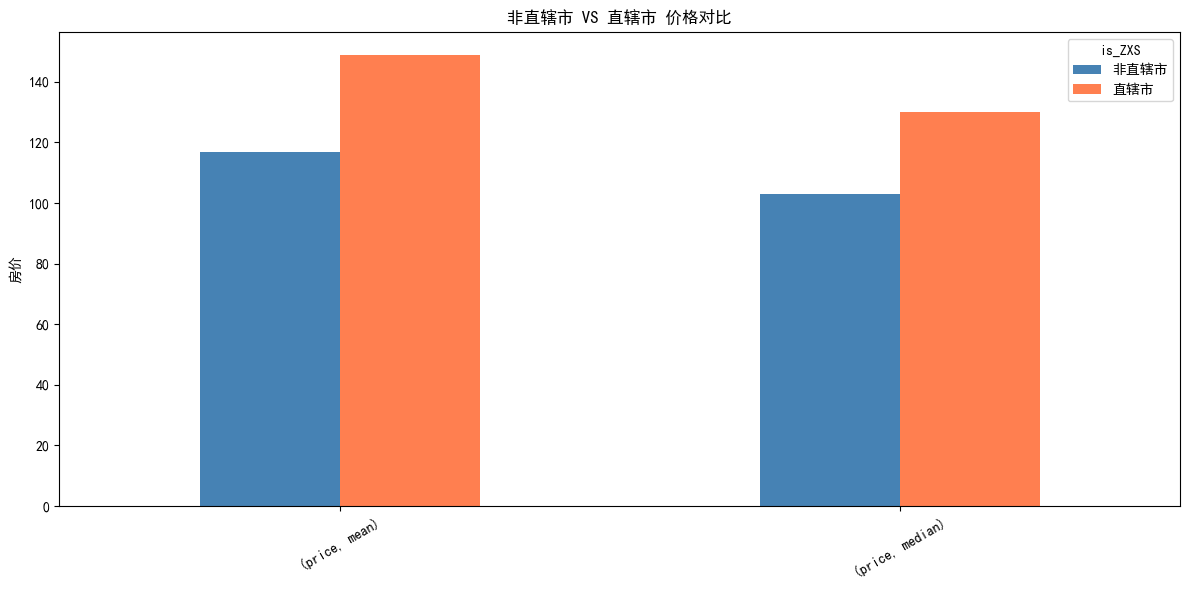

In [44]:
# 直辖市和普通股城市的区别

city_stats_zxs = df.groupby('is_ZXS').agg({
    'price': ['mean', 'median'],
    # 'unit': ['mean', 'median'],
})

city_stats_zxs.rename(index={0 : "非直辖市", 1 : "直辖市"}, inplace=True)
ax = city_stats_zxs.T.plot(kind='bar', figsize=(12,6), color=['steelblue', 'coral'])
print(city_stats_zxs)
plt.xticks(rotation=30)
plt.ylabel("房价")
plt.title("非直辖市 VS 直辖市 价格对比")
plt.tight_layout()
plt.show()

各层级的对比：


area                age     unit    nfloors         \
                   mean  median       mean   median       mean median   
price_label                                                             
低价            87.268551   89.00  12.443039   7059.0  19.367383   18.0   
中价           106.224389  102.00  12.796632  10909.0  20.909124   22.0   
高价           120.495043  118.51  13.796065  15979.5  21.165307   23.0   
豪华           135.724985  134.00  14.277942  19915.0  19.949734   18.0   

                        
            <lambda_0>  
price_label             
低价                   6  
中价                  18  
高价                  33  
豪华                  18

Text(0, 0.5, '楼龄')

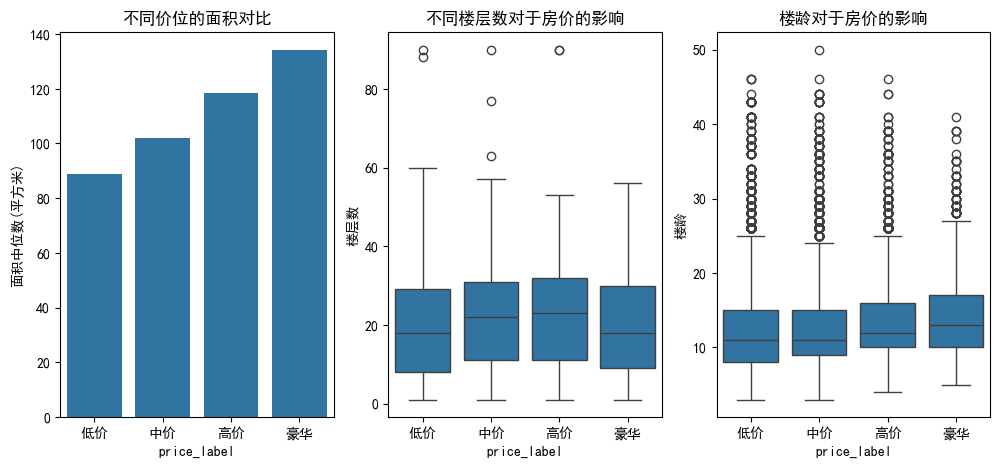

In [48]:
# 高价房在面积、楼层等方面有什么特征

price_group = df.groupby('price_label', observed=True).agg({
    'area': ['mean', 'median'],
    'age' : 'mean',
    'unit' : 'median',
    'nfloors' : ['mean', 'median', lambda x : x.mode()[0]],
})

print("各层级的对比：")
display(price_group)

plt.figure(figsize=(12,5))
plt.subplot(131)
sns.barplot(data=price_group, x='price_label', y=('area', 'median'))
plt.ylabel("面积中位数(平方米)")
plt.title("不同价位的面积对比")

plt.subplot(132)
sns.boxplot(data=df, x='price_label', y='nfloors')
plt.title("不同楼层数对于房价的影响")
plt.ylabel("楼层数")

plt.subplot(133)
sns.boxplot(data=df, x='price_label', y='age')
plt.title("楼龄对于房价的影响")
plt.ylabel("楼龄")

各户型市场表现：


price            unit
                mean median   median
bedrooms                            
1          61.327938   50.0  10779.0
0          69.384615   55.0  10000.0
2         102.952484   93.8  11504.0
3         123.399640  108.0   9818.0
4         152.806253  139.8   9859.0
8         160.000000  126.5   5043.0
7         163.500000  145.5   5580.0
5         167.835338  157.0   8696.0
9         182.250000  171.5   5141.5
6         195.852703  188.0   8504.5

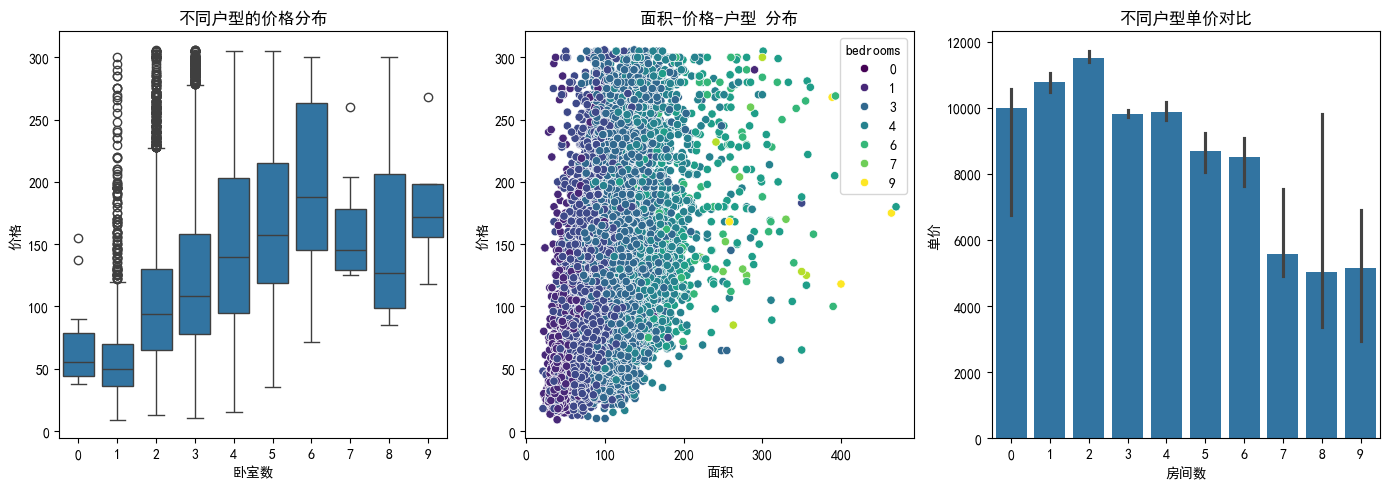

In [46]:
# 不同户型的价格差距
room_groups = df.groupby('bedrooms').agg({
    'price': ['mean', 'median'],
    'unit' : 'median',
}).sort_values(('price', 'mean'))
print("各户型市场表现：")
display(room_groups)

plt.figure(figsize=(14,5))
plt.subplot(131)
sns.boxplot(data=df, x='bedrooms', y='price')
plt.title("不同户型的价格分布")
plt.ylabel("价格")
plt.xlabel("卧室数")

plt.subplot(132)
sns.scatterplot(data=df, x='area', y='price',hue='bedrooms', palette='viridis')
plt.title("面积-价格-户型 分布")
plt.xlabel("面积")
plt.ylabel("价格")

plt.subplot(133)
sns.barplot(data=df, x='bedrooms', y='unit', estimator=np.median)
plt.title("不同户型单价对比")
plt.xlabel("房间数")
plt.ylabel("单价")

plt.tight_layout()
plt.show()

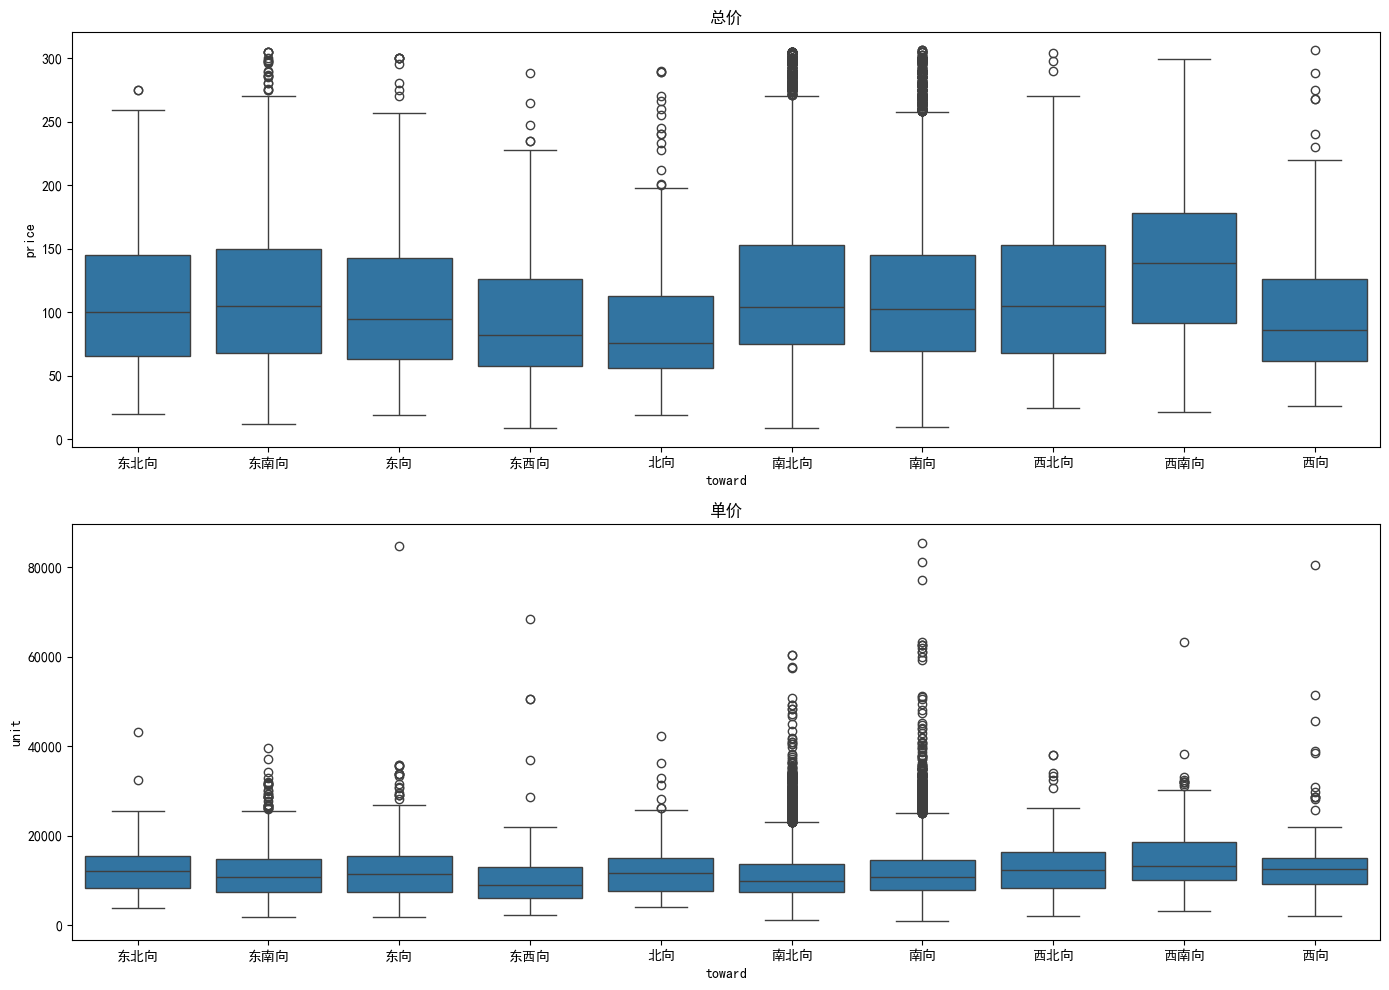

In [47]:
# 朝向对于价格的影响
toward_groups = df.groupby('toward', observed=False).agg({
    'price': ['mean', 'median'],
    'unit' : 'median',
})

plt.figure(figsize=(14,10))
plt.subplot(211)
sns.boxplot(data=df, x='toward', y='price')
plt.title("总价")
plt.subplot(212)
sns.boxplot(data=df, x='toward', y='unit')
plt.title("单价")
plt.tight_layout()
plt.show()